# 435 Final Presentation

Logistic Regression Example via ChatGPT




In [8]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Example dataset: [Age, Salary]
X = np.array([
    [22, 20000],
    [25, 25000],
    [47, 48000],
    [52, 52000],
    [46, 47000],
    [56, 60000],
    [23, 22000],
    [30, 30000]
])

# Target: 0 = did not purchase, 1 = purchased
y = np.array([0, 0, 1, 1, 1, 1, 0, 0])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Create logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, predictions)

print("Predictions:", predictions)
print("Accuracy:", accuracy)

Predictions: [0 0]
Accuracy: 1.0


In [9]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

PCA to identify relevant factors Example via ChatGPT


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Dataset: [Age, Salary, YearsExperience, RandomNoise]
X = np.array([
    [22, 20000, 1, 7],
    [25, 25000, 2, 3],
    [47, 48000, 20, 8],
    [52, 52000, 25, 2],
    [46, 47000, 18, 6],
    [56, 60000, 30, 1],
    [23, 22000, 1, 9],
    [30, 30000, 5, 4]
])

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA reducing to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Results
print("Principal Components:\n", X_pca)
print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)
print("\nComponent Loadings (importance of variables):\n", pca.components_)

cleaning attempt #1

In [ ]:
import numpy as np
import pandas as pd




#Retirement Age vs. Debt

In [7]:
import pandas as pd

# 1. Load the data from your Colab folder
path = "/content/Retirement age vs. Student debt.xlsx"
df = pd.read_excel(path)

# 2. Collapse the 'Five Implicates' (Essential for SCF data)
# This groups the 5 rows for every household (YY1) into 1 average row
df_clean = df.groupby('YY1').mean().reset_index()

# 3. Create a quick indicator for your analysis
df_clean['has_student_debt'] = (df_clean['EDN_INST'] > 0).astype(int)

# 4. See the results
print(f"Original file had {len(df)} rows.")
print(f"Cleaned file has {len(df_clean)} unique households.")
print("\nFirst 5 households in your cleaned data:")
print(df_clean[['YY1', 'AGE', 'EDN_INST', 'RETQLIQ']].head())

# 5. Save the cleaned file so you can download it or use it for charts
df_clean.to_csv("SCFP2022_cleaned_for_analysis.csv", index=False)

Original file had 22975 rows.
Cleaned file has 4595 unique households.

First 5 households in your cleaned data:
   YY1   AGE  EDN_INST    RETQLIQ
0    1  70.0       0.0   132200.0
1    2  46.0       0.0   100000.0
2    3  68.0       0.0   489200.0
3    4  74.0       0.0  1501000.0
4    5  19.0       0.0        0.0


In [10]:
import pandas as pd

# 1. Load the data
path = "/content/Retirement age vs. Student debt.xlsx"
df = pd.read_excel(path)

# 2. Define the "Translation" dictionary
# Format is 'Old_Name': 'New_Name'
name_mapping = {
    'YY1': 'Household_ID',
    'AGE': 'Age',
    'EDN_INST': 'Student_Debt',
    'RETQLIQ': 'Retirement_Savings',
    'INCOME': 'Annual_Income',
    'LIFECL': 'Life_Stage_Code',
    'WGT': 'Survey_Weight'
}

# 3. Apply the rename
df_renamed = df.rename(columns=name_mapping)

# 4. Collapse the data (using the new names now!)
df_clean = df_renamed.groupby('Household_ID').mean().reset_index()

# 5. Check the result
print("Your new variables are:")
print(df_clean[['Household_ID', 'Age', 'Student_Debt', 'Retirement_Savings']].head())

Your new variables are:
   Household_ID   Age  Student_Debt  Retirement_Savings
0             1  70.0           0.0            132200.0
1             2  46.0           0.0            100000.0
2             3  68.0           0.0            489200.0
3             4  74.0           0.0           1501000.0
4             5  19.0           0.0                 0.0


In [11]:
# 1. Filter for the 'Pre-Retirement' age group
pre_retirees = df_clean[(df_clean['Age'] >= 50) & (df_clean['Age'] <= 75)]

# 2. Split them into two groups: Those WITH debt and those WITHOUT
with_debt = pre_retirees[pre_retirees['Student_Debt'] > 0]
no_debt = pre_retirees[pre_retirees['Student_Debt'] == 0]

print(f"Number of households aged 50-65 with student debt: {len(with_debt)}")
print(f"Number of households aged 50-65 with NO student debt: {len(no_debt)}")

Number of households aged 50-65 with student debt: 233
Number of households aged 50-65 with NO student debt: 2144


In [12]:
# Calculate Median Retirement Savings
median_savings_debt = with_debt['Retirement_Savings'].median()
median_savings_no_debt = no_debt['Retirement_Savings'].median()

gap = median_savings_no_debt - median_savings_debt

print(f"Median Savings (With Debt): ${median_savings_debt:,.2f}")
print(f"Median Savings (No Debt): ${median_savings_no_debt:,.2f}")
print(f"The 'Retirement Gap' is: ${gap:,.2f}")

Median Savings (With Debt): $15,000.00
Median Savings (No Debt): $116,000.00
The 'Retirement Gap' is: $101,000.00


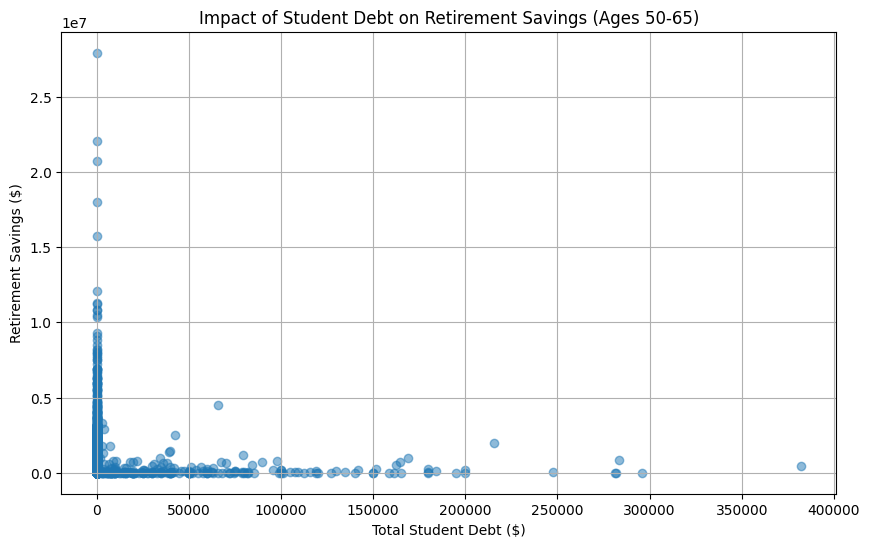

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(pre_retirees['Student_Debt'], pre_retirees['Retirement_Savings'], alpha=0.5)
plt.title('Impact of Student Debt on Retirement Savings (Ages 50-65)')
plt.xlabel('Total Student Debt ($)')
plt.ylabel('Retirement Savings ($)')
plt.grid(True)
plt.show()

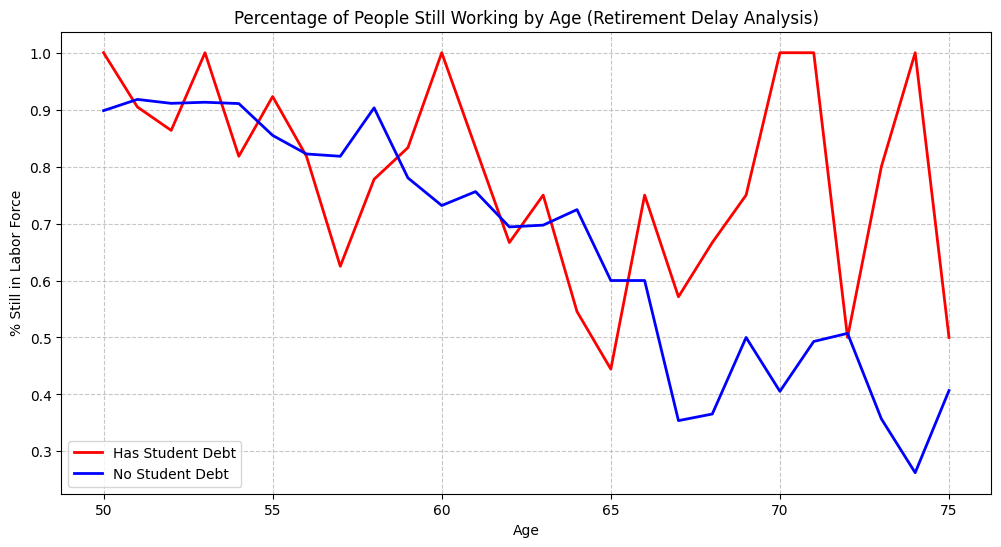

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load and Clean (if not already done)
df = pd.read_excel("/content/Retirement age vs. Student debt.xlsx")
df_clean = df.groupby('YY1').mean().reset_index()

# 2. Define our indicators
df_clean['has_student_debt'] = (df_clean['EDN_INST'] > 0).astype(int)
# LF = 1 means 'In Labor Force' (Working or looking for work)
# LF = 0 means 'Not in Labor Force' (Retired, disabled, or homemaker)

# 3. Filter for the "Retirement Transition" window (ages 50-75)
window = df_clean[(df_clean['AGE'] >= 50) & (df_clean['AGE'] <= 75)]

# 4. Calculate the % of people still working at each age
working_stats = window.groupby(['AGE', 'has_student_debt'])['LF'].mean().unstack()

# 5. Visualize the "Retirement Delay"
plt.figure(figsize=(12, 6))
plt.plot(working_stats.index, working_stats[1], label='Has Student Debt', color='red', linewidth=2)
plt.plot(working_stats.index, working_stats[0], label='No Student Debt', color='blue', linewidth=2)

plt.title('Percentage of People Still Working by Age (Retirement Delay Analysis)')
plt.xlabel('Age')
plt.ylabel('% Still in Labor Force')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

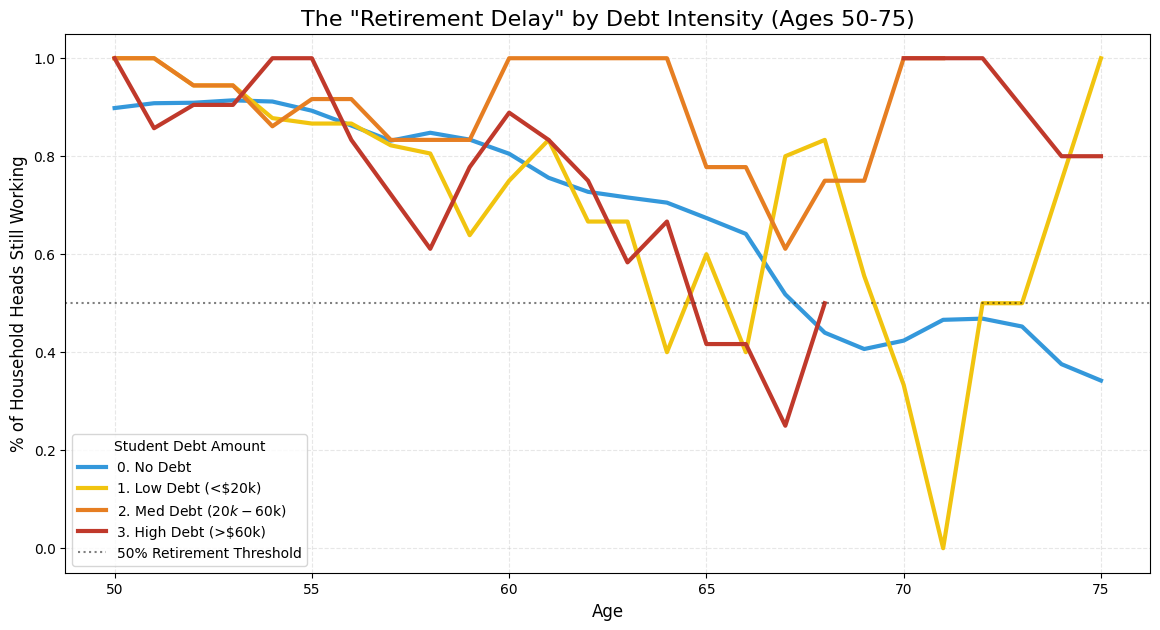

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Clean
df = pd.read_excel("/content/Retirement age vs. Student debt.xlsx")
df_clean = df.groupby('YY1').mean().reset_index()

# 2. Categorize Debt Amounts
# We'll create 4 groups to see the 'Intensity'
def debt_category(amount):
    if amount == 0: return '0. No Debt'
    elif amount < 20000: return '1. Low Debt (<$20k)'
    elif amount < 60000: return '2. Med Debt ($20k-$60k)'
    else: return '3. High Debt (>$60k)'

df_clean['Debt_Level'] = df_clean['EDN_INST'].apply(debt_category)

# 3. Filter for Retirement Window
window = df_clean[(df_clean['AGE'] >= 50) & (df_clean['AGE'] <= 75)]

# 4. Calculate % Still Working by Age AND Debt Level
# This creates a table where rows are Age and columns are Debt Levels
debt_stats = window.groupby(['AGE', 'Debt_Level'])['LF'].mean().unstack()

# 5. Visualize with a "Gradient" of colors
plt.figure(figsize=(14, 7))

# Plot each level with increasing darkness/intensity of color
colors = ['#3498db', '#f1c40f', '#e67e22', '#c0392b'] # Blue to Deep Red
for i, column in enumerate(debt_stats.columns):
    # We use a rolling mean (window=3) to smooth out the "jumpy" survey data
    smoothed_data = debt_stats[column].rolling(window=3, min_periods=1).mean()
    plt.plot(debt_stats.index, smoothed_data, label=column, color=colors[i], linewidth=3)

# 6. Formatting for the Capstone
plt.title('The "Retirement Delay" by Debt Intensity (Ages 50-75)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('% of Household Heads Still Working', fontsize=12)
plt.axhline(0.5, color='black', linestyle=':', alpha=0.5, label='50% Retirement Threshold')

plt.legend(title="Student Debt Amount", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [16]:
import pandas as pd
import statsmodels.api as sm

# 1. Load and Clean the data
path = "/content/Retirement age vs. Student debt.xlsx"
df = pd.read_excel(path)

# Collapse the 5 implicates (Averaging)
df_clean = df.groupby('YY1').mean().reset_index()

# 2. Prepare the Variables
# Dependent Variable (y): 1 if working, 0 if retired
y = df_clean['LF']

# Independent Variables (X): Student Debt, Age, Income, and Education
# We add a 'const' (intercept) for the math to work correctly
X = df_clean[['EDN_INST', 'AGE', 'INCOME', 'EDUC']]
X = sm.add_constant(X)

# 3. Filter for the 'Retirement Window'
# Analysis is most accurate if we look at people aged 50-75
mask = (df_clean['AGE'] >= 50) & (df_clean['AGE'] <= 75)
y_sub = y[mask]
X_sub = X[mask]

# 4. Run the Logit Regression
model = sm.Logit(y_sub, X_sub).fit()

# 5. Print the Results
print(model.summary())

# 6. Calculate "Marginal Effects" (This makes it easy to read)
# This tells you exactly how much the % chance of working changes per $1 of debt
print("\n--- Impact Analysis ---")
print(model.get_margeff().summary())

Optimization terminated successfully.
         Current function value: 0.517014
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                     LF   No. Observations:                 2377
Model:                          Logit   Df Residuals:                     2372
Method:                           MLE   Df Model:                            4
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.1827
Time:                        18:08:03   Log-Likelihood:                -1228.9
converged:                       True   LL-Null:                       -1503.6
Covariance Type:            nonrobust   LLR p-value:                1.464e-117
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3722      0.512     16.336      0.000       7.368       9.377
EDN_INST   -4.516e-07   2.14e

AGE (-0.1475): This is the strongest predictor. The negative coefficient means as you get older, the probability of working drops significantly.

INCOME (Positive): This shows that higher-income households are actually more likely to stay in the labor force. In the SCF, this often reflects "Career Professionals" (doctors, lawyers, executives) who enjoy their work or have high-demand skills that keep them working longer.

EDUC (0.1524): For every "level" of education reached, the probability of still working increases

In [18]:
#improved linear regression code
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Clean
df_clean = df.groupby('YY1').mean().reset_index()

# 2. Rescale for Math Analysis clarity
# Dividing by 10,000 makes a "1 unit change" equal to $10k in debt
df_clean['Debt_10k'] = df_clean['EDN_INST'] / 10000
df_clean['Income_10k'] = df_clean['INCOME'] / 10000

# 3. Create the Interaction Term (Does debt impact 60-year-olds differently?)
df_clean['Age_x_Debt'] = df_clean['AGE'] * df_clean['Debt_10k']

# 4. Filter for your "Retirement Window" (Age 50-75)
df_sub = df_clean[(df_clean['AGE'] >= 50) & (df_clean['AGE'] <= 75)].copy()

# 5. Define variables
# We use the scaled versions now!
X = df_sub[['AGE', 'Debt_10k', 'Age_x_Debt', 'Income_10k', 'EDUC']]
X = sm.add_constant(X)
y = df_sub['LF']

# 6. Run the New Model
new_model = sm.Logit(y, X).fit()
print(new_model.summary())



Optimization terminated successfully.
         Current function value: 0.515872
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                     LF   No. Observations:                 2377
Model:                          Logit   Df Residuals:                     2371
Method:                           MLE   Df Model:                            5
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.1845
Time:                        18:32:07   Log-Likelihood:                -1226.2
converged:                       True   LL-Null:                       -1503.6
Covariance Type:            nonrobust   LLR p-value:                1.227e-117
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.5943      0.523     16.428      0.000       7.569       9.620
AGE           -0.1512      0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Load and Clean (ensure the path matches your Colab)
path = "/content/Retirement age vs. Student debt.xlsx"
df = pd.read_excel(path)
df_clean = df.groupby('YY1').mean().reset_index()

# 2. Create the Indicator: 1 if they have debt, 0 if not
df_clean['has_student_debt'] = (df_clean['EDN_INST'] > 0).astype(int)

# 3. Filter for the 'Retirement window' (Ages 50-75)
window = df_clean[(df_clean['AGE'] >= 50) & (df_clean['AGE'] <= 75)].copy()

# 4. Run the Logit Regression
y = window['LF'] # 1=Working, 0=Retired
X = window[['AGE', 'has_student_debt']]
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()

# 5. Generate data for the lines
age_range = np.linspace(50, 75, 100)
# Create a scenario for 'No Debt'
no_debt_data = pd.DataFrame({'const': 1, 'AGE': age_range, 'has_student_debt': 0})
# Create a scenario for 'Has Debt'
with_debt_data = pd.DataFrame({'const': 1, 'AGE': age_range, 'has_student_debt': 1})

# 6. Predict the Probabilities
prob_no_debt = model.predict(no_debt_data)
prob_with_debt = model.predict(with_debt_data)

# 7. Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(age_range, prob_no_debt, label='No Student Debt', color='blue', linewidth=3)
plt.plot(age_range, prob_with_debt, label='Has Student Debt', color='red', linewidth=3, linestyle='--')

# Styling
plt.title('Predicted Probability of Still Working by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Probability of Being in Labor Force (LF=1)', fontsize=12)
plt.axhline(0.5, color='gray', linestyle=':', label='50% Retirement Threshold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import statsmodels.api as sm

# 1. Scale the debt to make the coefficients readable ($10,000 units)
df_clean['Debt_10k'] = df_clean['Student_Debt'] / 10000

# 2. Create the Interaction Term (Age * Debt)
df_clean['Age_x_Debt'] = df_clean['Age'] * df_clean['Debt_10k']

# 3. Define your Independent Variables (X) and Dependent Variable (y)
# We include the originals PLUS the new interaction term
X = df_clean[['Age', 'Debt_10k', 'Age_x_Debt', 'Annual_Income', 'Life_Stage_Code']]
X = sm.add_constant(X)
y = df_clean['LF'] # Labor Force Participation (1 or 0)

# 4. Run the Logit Model
model_interaction = sm.Logit(y, X).fit()

# 5. Check the results
print(model_interaction.summary())

In [ ]:
# vittoria quaranta. debt vs investment
